# Proyecto Final — Módulo 6

## Tema: Población adulta estadounidense (1994) con ingreso anual > $50K USD

| **Campo** | **Detalle** |
|---|---|
| **Grupo** | 2 |
| **Integrantes** | Cinthia Montero, Sebastián Calvo |
| **Curso** | Ciencia de Datos |
| **Fecha de Entrega** | 04 Setiembre 2026 |

---


# Problema:  
# Averigüar las características de la poblacióna adulta estadounidense del año 1994 que tenía ingresos anuales mayores a $ 50K USD y predecir sus futuros comportamientos.

# Objetivo:
# Identificar características que sean claves para determinar patrones que desarrollen individuos de la población que generen un ingreso anual mayor a $ 50K USD.

# **ETAPAS :**

# 2. Ingesta

In [2]:
# Librerías para manipulación y análisis de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Permite visualizar todas las columnas del DataFrame
pd.set_option('display.max_columns', None)

import os
os.environ["OMP_NUM_THREADS"] = "5"

In [4]:
# Instalamos 

!pip install ucimlrepo


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Descargamos dataset de https://archive.ics.uci.edu/dataset/2/adult?utm_source=chatgpt.com

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

# 3. Data Quality

## 3.1 Identificación de valores y tipos de dato.

Primeramente identificamos valores faltantes, simbolos insuales, tipos de dato incongrüentes y valores nulos.

Para este caso en particular al tratarse de un Censo se asume que los valores ya fueron previamente revisados y no se estan duplicando datos. Este dataset no cuenta con alguna columna con datos de identificación ó datos singulares y únicos que permitan confirmar que la información no es duplicada.  No obstante se hace una revisión para hacer constar el peso de los datos duplicados sobre el total del dataset.


In [6]:
# Redondeamos a dos decimales
pd.set_option('display.float_format', '{:.2f}'.format)

In [7]:
# Visualizamos las 5 filas para validación

df = pd.concat([X, y], axis=1)
display(df.sample(5))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5191,17,Private,156501,12th,8,Never-married,Other-service,Own-child,White,Female,0,0,16,United-States,<=50K
7483,18,Private,120544,9th,5,Never-married,Other-service,Own-child,Black,Male,0,0,15,United-States,<=50K
6554,40,Local-gov,55363,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
5519,19,Private,227491,HS-grad,9,Never-married,Sales,Not-in-family,Asian-Pac-Islander,Female,0,0,40,United-States,<=50K
43931,50,Private,330142,Some-college,10,Married-civ-spouse,Other-service,Husband,White,Male,0,0,44,United-States,<=50K.


In [8]:
# Dimensiones del dataset

print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")    # cantidad de filas y columnas

El dataset contiene 48842 filas y 15 columnas.


In [9]:
# Nombres de las columnas del dataset
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

In [10]:
# Información general y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## 3.2 Valores Duplicados 

In [11]:
# Duplicados exactos (todas las columnas, incluyendo fnlwgt)
duplicados = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

total_duplicados = df.duplicated().sum()  # solo las copias "de más"
total_filas_involucradas = duplicados.shape[0]  # original + copia

print(f'Total de filas duplicadas (copias de más): {total_duplicados}')
print(f'Peso relativo sobre el total del dataset: {total_duplicados / len(df) * 100:.2f}%')
print()

duplicados.head(8)

Total de filas duplicadas (copias de más): 29
Peso relativo sobre el total del dataset: 0.06%



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
36461,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K.
48521,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K.
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K


### Hallazgos sobre valores duplicados:

Se encuentran 29 filas que parecen ser duplicadas, sin embargo no se cuenta con el suficiente fundamento para determinar si realmente son valores duplicados ó bien se trata de registros identicos mas no duplicados. Se deciden conservar aquellas filas que parecen duplicadas.

## 3.3 Valores Nulos

Se valida la existencia de valores nulos, revisamos tanto el formato del valor nulo convertido mediante repositorio **ucimlrepo** como también su formato original.

Detectamos que la librería de origen no normalizó el símbolo de faltante de forma consistente, por lo que unificamos ambas codificaciones antes de continuar.

Revisaremos la existencia de los siguientes símbolos que representan en este dataset valores nulos ó faltantes: "NaN", "?" y " ".

In [12]:
# Cantidad de nulos por columna
df.isnull().sum()

# Solo las columnas que sí tienen nulos, con porcentaje
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pd.DataFrame({
    'Valores faltantes': nulos,
    'Porcentaje (%)': (nulos / len(df) * 100).round(2)
})

,Valores faltantes,Porcentaje (%)
occupation,966,1.98
workclass,963,1.97
native-country,274,0.56


In [13]:
# Verificación de nulos en formato original de dataset.

(df == '?').sum()[lambda x: x > 0]

workclass         1836
occupation        1843
native-country     583
dtype: int64

In [14]:
# Busca strings vacíos o que son solo espacios en las columnas de texto
cols_obj = df.select_dtypes(include='object').columns

vacios = {}
for col in cols_obj:
    n = (df[col].astype(str).str.strip() == '').sum()
    if n > 0:
        vacios[col] = n

print('Columnas con celdas vacías/solo espacios:', vacios or 'ninguna')

Columnas con celdas vacías/solo espacios: ninguna


In [15]:
nulos_nan = df.isnull().sum()
nulos_signo = (df == '?').sum()
total_faltantes = nulos_nan.add(nulos_signo, fill_value=0)
total_faltantes = total_faltantes[total_faltantes > 0].sort_values(ascending=False)
pd.DataFrame({
    'Valores faltantes': total_faltantes.astype(int),
    'Porcentaje (%)': (total_faltantes / len(df) * 100).round(2)
})

,Valores faltantes,Porcentaje (%)
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


In [16]:
pd.set_option('display.max_columns', None)

df[df[['workclass','occupation','native-country']].isnull().any(axis=1) |
   (df[['workclass','occupation','native-country']] == '?').any(axis=1)].sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
16817,66,?,206560,HS-grad,9,Widowed,?,Not-in-family,Other,Female,0,0,35,Puerto-Rico,<=50K
40281,23,Private,239539,Some-college,10,Never-married,Craft-repair,Own-child,Asian-Pac-Islander,Male,0,0,40,NaN,>50K.
43317,70,NaN,98979,Some-college,10,Married-civ-spouse,NaN,Husband,Black,Male,0,0,20,United-States,>50K.
35644,64,NaN,223075,Bachelors,13,Divorced,NaN,Not-in-family,White,Female,0,0,8,United-States,<=50K.
18337,30,?,159589,Masters,14,Married-civ-spouse,?,Husband,White,Male,0,0,46,United-States,>50K


### Hallazgos de valores faltantes: 

Se encuentran 6,465 celdas con valores nulos. Sin embargo por categoría los valores nulos representan aproximadamente entre un 5% y un 6% para las columnas de "occupation" y "worldclass", y para la columna "native-country" este representa apenas un 1.75%.   

## 3.4 Imputación

Debido a los valores faltantes representan aproximadamente un 5% aproximadamente ó inclusive un valor menor del total de cada columna y a la vez al tratarse de datos de tipo cualitativos, **imputaremos con base en la moda**.

In [17]:
cols_con_nulos = ['workclass', 'occupation', 'native-country']

# Moda de cada columna (ignora nulos y "?")
modas = {}
for col in cols_con_nulos:
    moda = df.loc[~df[col].isnull() & (df[col] != '?'), col].mode()[0]
    modas[col] = moda
    print(f'{col}: moda = {moda}')

workclass: moda = Private
occupation: moda = Prof-specialty
native-country: moda = United-States


In [18]:
# Imputación: reemplaza NaN y "?" por la moda de cada columna
df_clean = df.copy()

for col in cols_con_nulos:
    df_clean[col] = df_clean[col].replace('?', modas[col])
    df_clean[col] = df_clean[col].fillna(modas[col])

# Verificación
print(df_clean[cols_con_nulos].isnull().sum())
print((df_clean[cols_con_nulos] == '?').sum())

workclass         0
occupation        0
native-country    0
dtype: int64
workclass         0
occupation        0
native-country    0
dtype: int64


Imputacion de punto (.) al final del valor en columna "income".

In [19]:
# Quita el punto final para unificar "<=50K." con "<=50K" y ">50K." con ">50K"
df['income'] = df['income'].str.rstrip('.')

# Verificación
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [20]:
df_clean['income'] = df_clean['income'].str.rstrip('.')
df_clean['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [21]:
df_clean.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
37511,35,Self-emp-not-inc,99357,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,40,United-States,>50K
33627,50,Private,158948,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,84,United-States,<=50K
14311,33,Private,136331,HS-grad,9,Married-spouse-absent,Craft-repair,Unmarried,White,Male,0,0,50,United-States,<=50K
26808,35,Private,117567,HS-grad,9,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
14669,31,Private,182539,Some-college,10,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,45,United-States,<=50K


### Hallazgos de Imputación:

Se imputan los datos nulos identificados tanto con simbolo "NaN" como con simbolo "?", dejando en cero la cantidad de datos nulos.

También se limpia un punto (.) en la columna "income" reduciendo la cantidad de categorías para esa variable a dos únicamente.

### 3.5 Cambio de Tipo de Dato

Se identifica que la variable "**income**" solamente contiene dos categorías, por lo tanto para facilitar su clasificación se opta por cambiar su tipo de dato a valor booleano (cualitativo).

In [22]:
# Cambiamos tipo de dato de las variables : "income" y "sex" a booloeano ya que solo tienen dos categorías.

df['income'] = df['income'].map({'<=50K': False, '>50K': True})
df['sex'] = df['sex'].map({'Male': True, 'Female': False})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  bool  
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  bool  
dtypes: bool(2), int64(6), object(7)
memory usage: 4.9+ MB


## 3.6 Primer Fase - Análisis de Estadística Descriptiva

### Variables cuantitativas:

| N | Column | Non-Null Count | Dtype |
|---|---|---|---|
| 0 | age | 48842 non-null | int64 |
| 2 | fnlwgt | 48842 non-null | int64 |
| 4 | education-num | 48842 non-null | int64 |
| 10 | capital-gain | 48842 non-null | int64 |
| 11 | capital-loss | 48842 non-null | int64 |
| 12 | hours-per-week | 48842 non-null | int64 |

### Variables cualitativas:

| N | Column | Non-Null Count | Dtype |
|---|---|---|---|
| 1 | workclass | 47879 non-null | object |
| 3 | education | 48842 non-null | object |
| 5 | marital-status | 48842 non-null | object |
| 6 | occupation | 47876 non-null | object |
| 7 | relationship | 48842 non-null | object |
| 8 | race | 48842 non-null | object |
| 9 | sex | 48842 non-null | bool |
| 13 | native-country | 48568 non-null | object |
| 14 | income | 48842 non-null | bool |

### 3.6.1 Estadística descriptiva de variables cuantitativas: 

Se reconocen 6 variables cuantitativas, en primera instancia se les analiza las medidas de tendencia central: promedio, desviación estándar y percentiles; y también medidas de posicionamiento: mediana y rangos (min-max):



In [23]:
# Lista de variables cuantitativas
vars_cuantitativas = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']



In [24]:
# Estadística descriptiva de variables cuantitativas:

resumen = df[vars_cuantitativas].describe().T
resumen['rango'] = resumen['max'] - resumen['min']
resumen['mediana'] = df[vars_cuantitativas].median()
resumen

,count,mean,std,min,25%,50%,75%,max,rango,mediana
age,48842.00,38.64,13.71,17.00,28.00,37.00,48.00,90.00,73.00,37.00
fnlwgt,48842.00,189664.13,105604.03,12285.00,117550.50,178144.50,237642.00,1490400.00,1478115.00,178144.50
education-num,48842.00,10.08,2.57,1.00,9.00,10.00,12.00,16.00,15.00,10.00
capital-gain,48842.00,1079.07,7452.02,0.00,0.00,0.00,0.00,99999.00,99999.00,0.00
capital-loss,48842.00,87.50,403.00,0.00,0.00,0.00,0.00,4356.00,4356.00,0.00
hours-per-week,48842.00,40.42,12.39,1.00,40.00,40.00,45.00,99.00,98.00,40.00


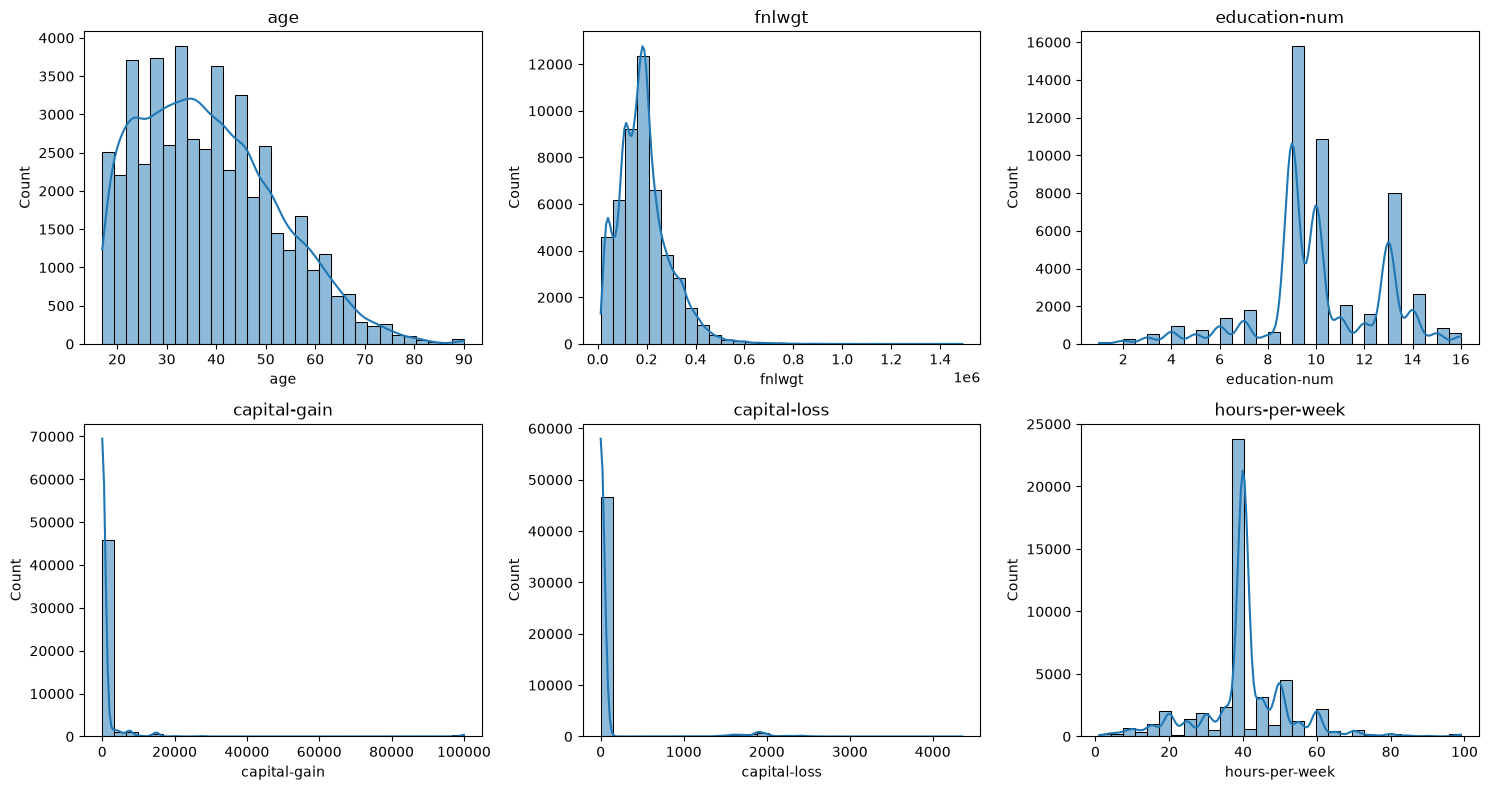

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_cuantitativas):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Descripción de las variables cuantitativas:

- **age**: su rango va de 17 a 90 años, con un promedio de 38.6 y mediana 37, bastante cercanas, lo que indica una distribución razonablemente simétrica.

- **fnlwgt**: rango muy amplio (12.285 a 1.490.400) y media (189.664) bastante más alta que la mediana (178.144). Distribución asimétrica cesgada a la derecha (contiene valores extremos).

- **education-num**: A pesar de su baja cardinalidad, es una variable cuantitativa ordinal (no continua), su rango se extiende de 1 a 16 y esto nos genera un orden sobre el rango permitiendo considerar la escala educativa para predecir mediante calculos la generación de ingresos económicos . La media es 10.08 y la mediana 10, se comporta de manera simétrica. 

- **capital-gain**: el 91.7% de las personas tiene capital-gain igual a 0. La media (1079) está muy por encima de la mediana (0). Distribución asimétrica cesgada a la derecha. Importante confirmar que el valor máximo registrado es de 99,999 USD. Monto que puede ser mayor sin embargo el documento original así lo estableció. (contiene valores extremos) 

- **capital-loss**: 95.3% en cero, media 87.5 contra una mediana de 0. Distribución asimétrica cesgada a la derecha (contiene valores extremos).

- **hours-per-week**: es una variable con distribución bastante simétrica.

### 3.6.2 Estadística descriptiva de variables cualitativas:

Se identificaron 9 variables cualitativas a las cuales se les analizó las siguientes estadísticas: dato moda para cada variable cualitativa, la frecuencia absoluta, y cuánto representa el dato moda del total de registros de cada una de las variables. 

In [26]:
vars_cualitativas = ['workclass', 'education', 'marital-status', 'occupation',
                      'relationship', 'race', 'sex', 'native-country', 'income']

resumen_cat = df_clean[vars_cualitativas].describe().T
resumen_cat['freq'] = pd.to_numeric(resumen_cat['freq'])
resumen_cat['count'] = pd.to_numeric(resumen_cat['count'])
resumen_cat['unique'] = pd.to_numeric(resumen_cat['unique'])

resumen_cat['% de la moda'] = (resumen_cat['freq'] / len(df_clean) * 100).round(2)
resumen_cat

,count,unique,top,freq,% de la moda
workclass,48842,8,Private,36705,75.15
education,48842,16,HS-grad,15784,32.32
marital-status,48842,7,Married-civ-spouse,22379,45.82
occupation,48842,14,Prof-specialty,8981,18.39
relationship,48842,6,Husband,19716,40.37
race,48842,5,White,41762,85.50
sex,48842,2,Male,32650,66.85
native-country,48842,41,United-States,44689,91.50
income,48842,2,<=50K,37155,76.07


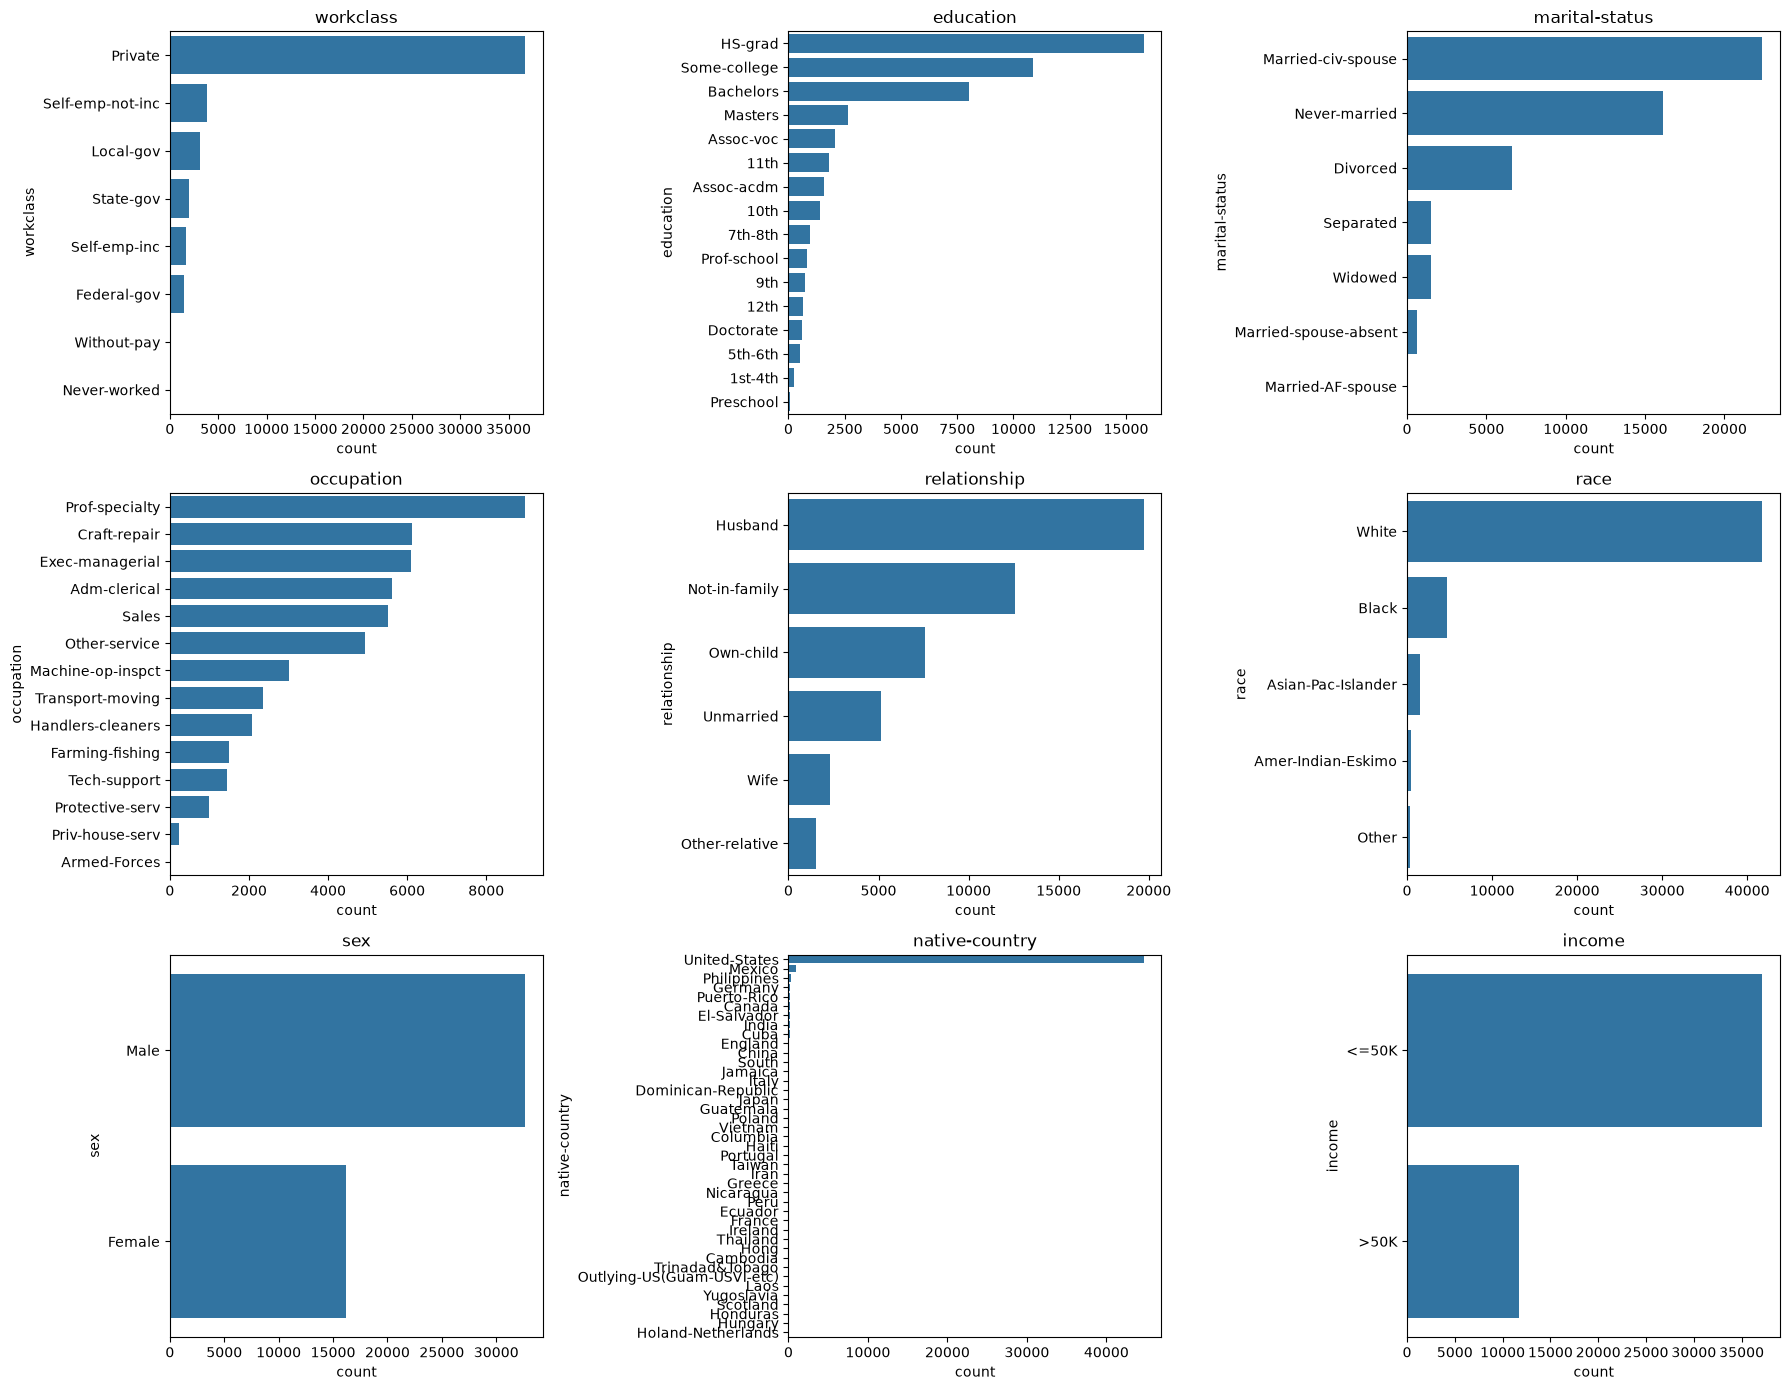

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    orden = df_clean[col].value_counts().index
    sns.countplot(y=df_clean[col], order=orden, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Descripción de las estadísticas cualitativas por variable:


- **workclass**: 8 categorías, dominada 75.15% por "Private", es la categoría claramente mayoritaria del mundo laboral en EE.UU. de 1994. 

- **education**: 16 categorías, la moda es "HS-grad" con solo un 32.32% del total de registros.

- **marital-status**: 7 categorías, la moda fue "Married-civ-spouse" con 45.82% del total de registros. Casi la mitad de la población se encuentra formando parte de un matrimonio.

- **occupation**: 14 categorías, "Prof-specialty" es la moda con apenas un 18% del total de registros, es una variable categórica que se ha repartido de manera más equitativa.

- **relationship**: 6 categorías, la moda es: "Husband" 40%, casi la mitad de la población aproximadamente. 

- **race**: 5 categorías, "White" con 85.5% de la población encuestada en el año 1994 en Estados Unidos era de etnia blanca. 

- **sex**: categoría binaria, La moda fue "Male" 66.85% del total de personas.

- **native-country**: 41 categorías, dominada 91.5% por "United-States". El resto de los 41 países se reparten menos del 9%.

- **income**: categoría binaria, 76.07% de la población tiene un ingreso anual menor ó igual a los 50 mil dólares. 



# 3.7 Segunda Fase - Análisis de Estadística Descriptiva



- **Anomalías estadísticas:**  

- **Skewness:**

- **Valores extremos:**

- **Imbalance:**

- **Correlación excesiva:**

- **Leakage:**

- **Gaps temporales:**






## 3.7.1 Cardinalidad
- **Cualitativa:**  La cardinalidad  ó cantidad de categorías de cada variable, es indicada por la columna "unique" en la tabla anterior. (punto 3.6.2) 

- **Cuantitativa:** La indica la columna "rango" en la tabla anterior (punto 3.6.1)

In [28]:
todas_las_vars = vars_cuantitativas + vars_cualitativas

cardinalidad_total = df_clean[todas_las_vars].nunique().sort_values(ascending=False)
cardinalidad_total = pd.DataFrame({
    'cardinalidad': cardinalidad_total,
    '% del total de filas': (cardinalidad_total / len(df_clean) * 100).round(4),
    'tipo': ['cuantitativa' if c in vars_cuantitativas else 'cualitativa' for c in cardinalidad_total.index]
})
cardinalidad_total

,cardinalidad,% del total de filas,tipo
fnlwgt,28523,58.40,cuantitativa
capital-gain,123,0.25,cuantitativa
capital-loss,99,0.20,cuantitativa
hours-per-week,96,0.20,cuantitativa
age,74,0.15,cuantitativa
native-country,41,0.08,cualitativa
education-num,16,0.03,cuantitativa
education,16,0.03,cualitativa
occupation,14,0.03,cualitativa
workclass,8,0.02,cualitativa


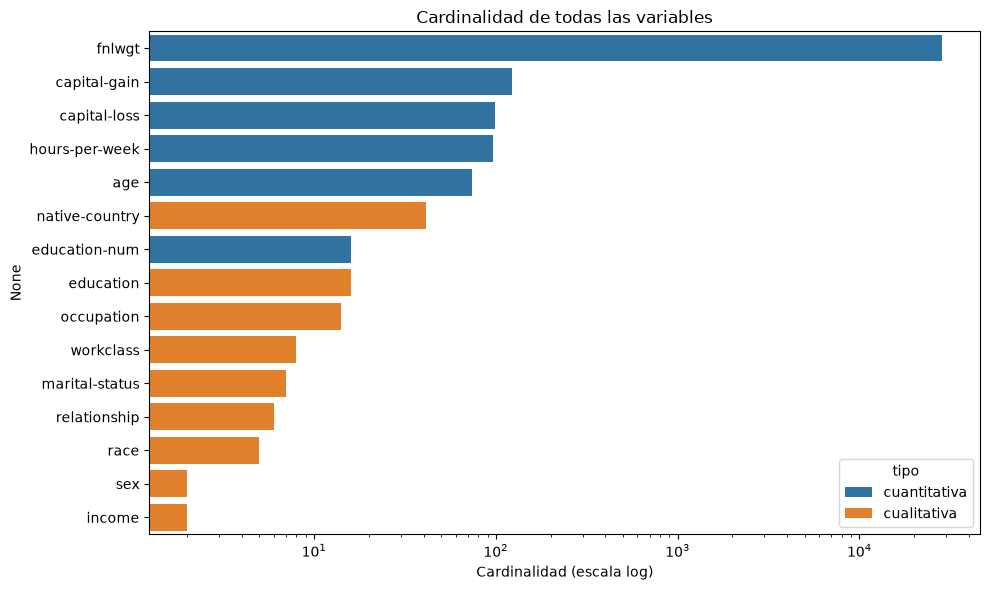

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cardinalidad_total['cardinalidad'], y=cardinalidad_total.index,
            hue=cardinalidad_total['tipo'], dodge=False)
plt.xscale('log')
plt.xlabel('Cardinalidad (escala log)')
plt.title('Cardinalidad de todas las variables')
plt.tight_layout()
plt.show()

El gráfico muestra las variables ordenadas de forma ascendente según la cantidad de categorías por cada una de las variables. Se utiliza una escala logarítmica para equiparar los rangos de las variables tanto cuantitativas como cualitativas.

Las variables cualitativas tienen una cardinalidad menor a las variables cuantitativas, lo cual facilita su clasificación. Las variables cuantitativas se podrían segmentizar (discretización) para reducir el número de categorías facilitando así su clasificación.

#### 3.7.2 Errores de Unidad
A. Se realizan 6 chequeos para las siguientes variables:

- 1. Revisión de tipos de datos actuales para variables cuantitativas
- 2. Valida la existencia de datos en formto decimal en variables cuantitativas
- 3. Confirma límite inferior en variable "capital-loss"
- 4. Confirma límite superior de rango en variable "age"
- 5. Confirma límite superior de rango en variable "hours-per-week"
- 6. Confirma límite superior de rango en variable "capital-gain"


In [30]:
# 1. El primero verifica que los tipos de datos correctos coincidan con lo que representan.
for col in vars_cuantitativas:
    print(f'{col}: dtype={df_clean[col].dtype}')

age: dtype=int64
fnlwgt: dtype=int64
education-num: dtype=int64
capital-gain: dtype=int64
capital-loss: dtype=int64
hours-per-week: dtype=int64


In [31]:
# 2. El segundo verifica que no haya valores con decimales donde se esperan números enteros. 

for col in vars_cuantitativas:
    con_decimales = (df_clean[col] % 1 != 0).sum()
    print(f'{col}: {con_decimales} filas con valores decimales')

age: 0 filas con valores decimales
fnlwgt: 0 filas con valores decimales
education-num: 0 filas con valores decimales
capital-gain: 0 filas con valores decimales
capital-loss: 0 filas con valores decimales
hours-per-week: 0 filas con valores decimales


In [32]:
# 3. El tercero confirma límite inferior de rango.

print('Filas con capital-loss = 4356 (posible tope de captura):', (df_clean['capital-loss'] == 4356).sum())

Filas con capital-loss = 4356 (posible tope de captura): 3


In [33]:
# 4. Confirma limite superior de rango en variable "age".
# 5. Confirma límite superior de rango en variable "hours-per-week". 

print('Filas con age = 90:', (df_clean['age'] == 90).sum())
print('Filas con hours-per-week = 99:', (df_clean['hours-per-week'] == 99).sum())

Filas con age = 90: 55
Filas con hours-per-week = 99: 137


In [34]:
# 6. Confirma límite superior de rango en variable: "capital-gain"

print('Filas con capital-gain = 99999 (posible limite de rango superior):', (df_clean['capital-gain'] == 99999).sum())

Filas con capital-gain = 99999 (posible limite de rango superior): 244


### Hallazgos de Errores de Unidad:

- Se confirma la inexistencia de tipos de datos nulos y flotantes en las variables cuantitativas.

- Se determina que las variables "capital-gain" y "capital-loss" se pueden trabajar como numeros enteros, facilita su clasificación y los decimales no agregan valor ni son relevantes.

- Se observan solamente 3 registros en variable "capital-loss" con un valor de 4,356 USD no obstante no se debe concluir que el 4,356 es un monto límite inferior establecido en el dataset original debido a que cuenta con muy pocos registros en esa categoría.

- La variable "capital-gain" muestra un tope superior por un valor de 99,999 USD y tienen 244 registros en esta categoría, lo cual indica que este límite superior del rango fue impuesto al momento de desarrollar el dataset. No obstante es probable que el monto original haya sido mayor a 99,999 USD.

- Las variables "age" y "hours-per-week" también muestran comportamiento como si tuviesen establecido un límite superior, la variable "age" tiene 55 registros con personas con 90 años exactos. La variable "hours-per-week" tiene 137 registros con personas que trabajan 99 horas a la semana. Siendo ambos casos imprecisos y muy posiblemente hayan registros con valores superiores en ambas categorías.


#### 3.7.3 Anomalías Estadísticas

Se hace una revisión cruzada entre variables específicas con la finalidad de validar coherencia de los resultados obtenidos, para ello se cruzaron las siguientes variables:

- **workclass vrs hours-per-week:** se valida la categoría "Never-worked" tenga cero horas reportadas en la variable "hours-per-week".

- **capital-gain vrs capital-loss:** garantiza exclusividad sobre la variable que reporte saldo. Sería incoherente que ambas variables reporten saldos.

- **education vrs education-num:** confirma singularidad entre las categorías de las dos variables.

In [35]:
# 1. Never-worked debería tener hours-per-week = 0 (o muy bajo)
print('Never-worked con horas trabajadas:')
print(df_clean[df_clean['workclass'] == 'Never-worked']['hours-per-week'].describe())

Never-worked con horas trabajadas:
count   10.00
mean    28.90
std     13.08
min      4.00
25%     22.50
50%     35.00
75%     38.75
max     40.00
Name: hours-per-week, dtype: float64


In [36]:
# 2. ¿Alguna fila tiene capital-gain Y capital-loss mayores a 0 al mismo tiempo?
ambos = (df_clean['capital-gain'] > 0) & (df_clean['capital-loss'] > 0)
print(f'Filas con capital-gain Y capital-loss > 0 simultáneamente: {ambos.sum()}')
df_clean[ambos].head()

Filas con capital-gain Y capital-loss > 0 simultáneamente: 0


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income


In [37]:
# 3. education vs education-num: cada texto de education debería mapear a un único número
mapeo = df_clean.groupby('education')['education-num'].nunique()
inconsistentes = mapeo[mapeo > 1]
print('Categorías de education con mapeo inconsistente:', inconsistentes.index.tolist() or 'ninguna')

Categorías de education con mapeo inconsistente: ninguna


### Hallazgos de Anomalías Estadísticas:

Se validan tres cruces de variables, tanto cuantitativas como cualitativas, con la finalidad de confirmar que los resultados en sus categorías sean matemáticamente coherentes. En los tres casos no se detectan incoherencias en cuánto a su lógica-matemática.



### 3.7.4 Skewness


Skewness ó Coeficiente de Asimetría nos indica que tan asimétrica es la distribución de los datos con respecto al promedio. Se aplica únicamente en variables cuantitativas.

In [38]:
skewness = df_clean[vars_cuantitativas].skew().sort_values(ascending=False)
skewness

capital-gain     11.89
capital-loss      4.57
fnlwgt            1.44
age               0.56
hours-per-week    0.24
education-num    -0.32
dtype: float64

### Hallazgos de Skewness:

Las variables **"capital-gain"**, con 11.89 puntos,  **"capital-loss"** con 4.57 puntos y **"fnlwgt"** con 1.44 puntos presentan una distribución de datos con asimetría positiva, más evidentemente en las primeras dos variables mencionadas puesto que son mucho mayores que el nivel de asimetría severo (igual a 1); las tres son candidatas a transformación (log1p u otra de mayor escala), mientras que las variables:  **"age"**, **"hours-per-week"** y **"education-num"** se pueden dejar tal como están.

### 3.7.5 Valores Extremos

Para identificar los valores extremos se usa el método IQR para la mayoría de variables cuantitativas, sin embargo hay dos variables a las cuales se les necesita aplicar un método alternativo debido a que en ambos casos más del 90% de los datos indican un mismo valor (0). Por tanto, el rango intercuartílico está cesgado, por ende se usa un percentil mayor para delimitar el cálculo e identificación de los valores extemos ó "outliers".

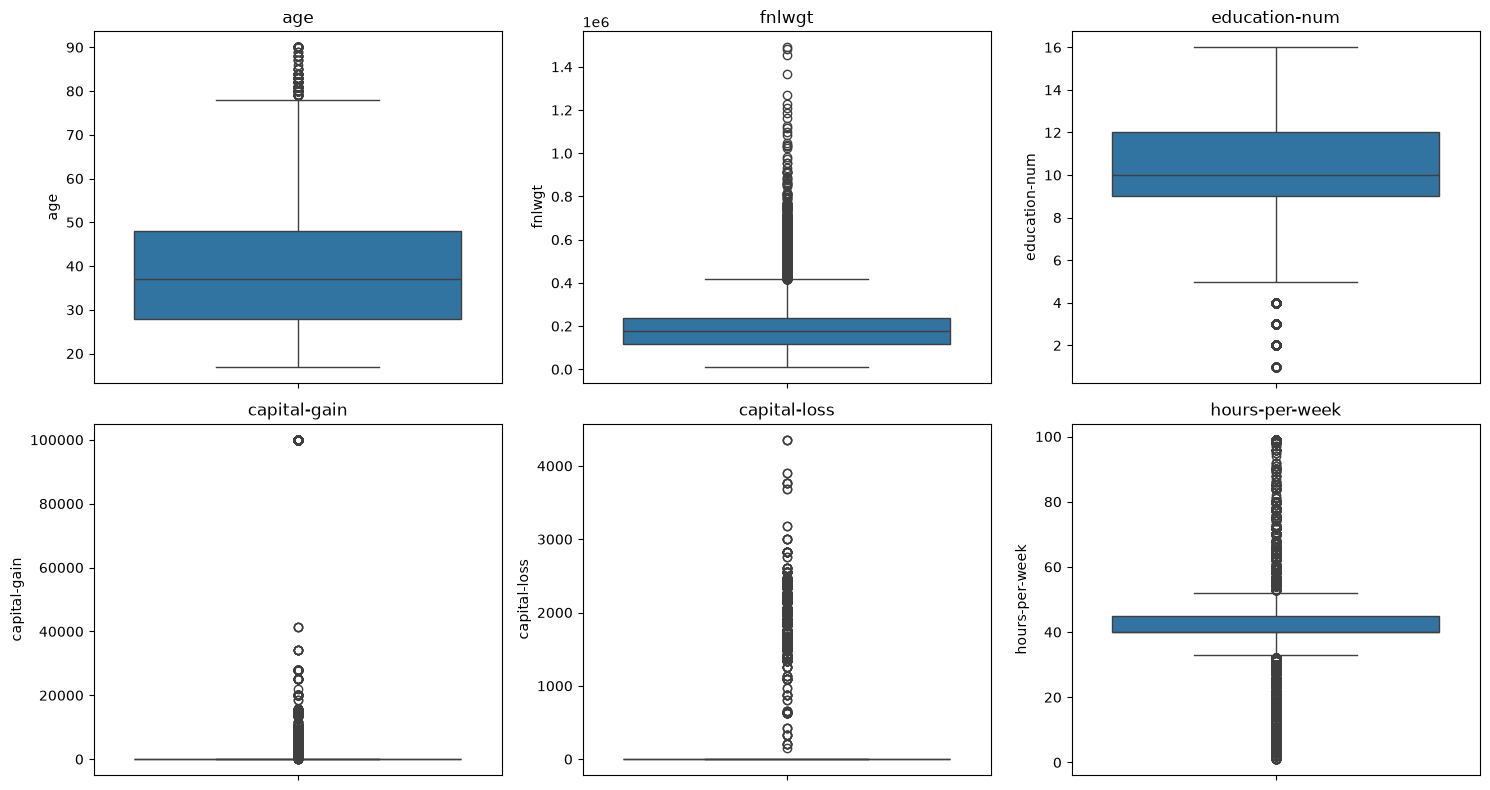

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_cuantitativas):
    sns.boxplot(y=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [40]:
for col in vars_cuantitativas:
    q1, q3 = df_clean[col].quantile(.25), df_clean[col].quantile(.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    print(f'{col}: IQR={iqr}, rango válido=[{low}, {high}], outliers={n_out} ({n_out/len(df_clean)*100:.2f}%)')

age: IQR=20.0, rango válido=[-2.0, 78.0], outliers=216 (0.44%)
fnlwgt: IQR=120091.5, rango válido=[-62586.75, 417779.25], outliers=1453 (2.97%)
education-num: IQR=3.0, rango válido=[4.5, 16.5], outliers=1794 (3.67%)
capital-gain: IQR=0.0, rango válido=[0.0, 0.0], outliers=4035 (8.26%)
capital-loss: IQR=0.0, rango válido=[0.0, 0.0], outliers=2282 (4.67%)
hours-per-week: IQR=5.0, rango válido=[32.5, 52.5], outliers=13496 (27.63%)


In [44]:
for col in ['capital-gain', 'capital-loss']:
    no_cero = df_clean[df_clean[col] > 0][col]
    p99 = no_cero.quantile(0.99)
    extremos = (no_cero > p99).sum()
    print(f'{col}: percentil 99 (entre no-ceros) = {p99}, {extremos} filas por encima de ese umbral')
    

capital-gain: percentil 99 (entre no-ceros) = 99999.0, 0 filas por encima de ese umbral
capital-loss: percentil 99 (entre no-ceros) = 2824.0, 18 filas por encima de ese umbral


In [47]:
for col in ['capital-gain', 'capital-loss']:
    no_cero = df_clean[df_clean[col] > 0][col]
    p99 = no_cero.quantile(0.99)
    valores_extremos = no_cero[no_cero > p99]
    extremos = len(valores_extremos)

    print(f'{col}:')
    print(f'  percentil 99 (entre no-ceros)   = {p99:,.0f}')
    print(f'  filas por encima de ese umbral  = {extremos}')

    # Si el percentil 99 coincide con el máximo, "por encima" da 0 siempre
    # (nadie puede superar un techo) -> se documenta como posible tope de captura
    if p99 == no_cero.max():
        en_maximo = (no_cero == no_cero.max()).sum()
        print(f'  -> el percentil 99 coincide con el máximo ({no_cero.max():,.0f}), probable tope de captura')
        print(f'  -> filas exactamente en ese máximo       = {en_maximo} ({en_maximo/len(no_cero)*100:.1f}% de los no-cero)')
    # Si sí hay filas por encima del umbral, se muestra qué valores concretos toman
    elif extremos > 0:
        print(f'  -> valores distintos por encima del umbral y su frecuencia:')
        for val, cnt in valores_extremos.value_counts().sort_index().items():
            print(f'       {int(val):>6,d}  ({cnt} filas)')
    print()

capital-gain:
  percentil 99 (entre no-ceros)   = 99,999
  filas por encima de ese umbral  = 0
  -> el percentil 99 coincide con el máximo (99,999), probable tope de captura
  -> filas exactamente en ese máximo       = 244 (6.0% de los no-cero)

capital-loss:
  percentil 99 (entre no-ceros)   = 2,824
  filas por encima de ese umbral  = 18
  -> valores distintos por encima del umbral y su frecuencia:
        3,004  (5 filas)
        3,175  (2 filas)
        3,683  (2 filas)
        3,770  (4 filas)
        3,900  (2 filas)
        4,356  (3 filas)



### Hallazgos de Valores Extremos

Se han identificado los valores extremos y su representación poblacional para cada variable, abajo los resultados:

- age :                     0.44%
- fnlwgt :                  2.97%
- education-num :           3.67%
- hours-per-week :          27.63%


Con el IQR clásico, las variables age, fnlwgt y education-num muestran pocos outliers (entre 0.4% y 3.7%), mientras que hours-per-week marca 27.63%, pero es un falso positivo: casi todos trabajan 40 horas, así que el IQR queda muy angosto y se prioriza el rango de negocio (1-99) en su lugar. 

En capital-gain y capital-loss el IQR directamente no sirve, porque más del 90% de los valores son cero y eso deja el rango en [0,0]. Por eso se usa el percentil 99 solo entre los valores no-cero: en capital-gain ese percentil cae justo en 99999, el tope de captura del Census Bureau, **así que los 244 casos ahí no son outliers reales** sino un artefacto del dataset. 

En capital-loss sí aparecen 18 casos genuinos por encima del percentil 99, repartidos en varios montos, lo que indica pérdidas de capital reales. Ninguno de los dos se elimina, porque ambas variables se van a transformar con log1p más adelante.









### 3.7.6 Imbalance

### 3.7.7 Correlación Excesiva

### 3.7.8 Leakage

### 3.7.9 Gaps Temporales